# Combined Emotion Detection Model
## Multi-Dataset + Multi-Model Training + Real-time Prediction

In [5]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: []


In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, 
                                       LSTM, Bidirectional, Input, GlobalAveragePooling1D, 
                                       MultiHeadAttention)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

output_dir = "combined_output"
os.makedirs(output_dir, exist_ok=True)

print("Imports complete ✅")

ModuleNotFoundError: No module named 'tensorflow.keras'

# Dataset Configuration

In [ ]:
data_directory = "/media/anshu/New Volume/Dataset"

emotion_map_number = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

crema_emotion_map = {
    "ANG": "angry", "DIS": "disgust", "FEA": "fearful", 
    "HAP": "happy", "NEU": "neutral", "SAD": "sad"
}

def get_all_wav_files():
    all_files = []
    
    ravdess_speech = glob.glob(os.path.join(data_directory, "Audio_Speech_Actors_01-24/**/*.wav"), recursive=True)
    ravdess_song = glob.glob(os.path.join(data_directory, "Audio_Song_Actors_01-24/**/*.wav"), recursive=True)
    crema_files = glob.glob(os.path.join(data_directory, "Crema/**/*.wav"), recursive=True)
    tess_disgust = glob.glob(os.path.join(data_directory, "Disgust/**/*.wav"), recursive=True)
    tess_neutral = glob.glob(os.path.join(data_directory, "neutral-dataset/**/*.wav"), recursive=True)
    
    all_files.extend(ravdess_speech)
    all_files.extend(ravdess_song)
    all_files.extend(crema_files)
    all_files.extend(tess_disgust)
    all_files.extend(tess_neutral)
    
    return all_files, {
        'RAVDESS_Speech': ravdess_speech,
        'RAVDESS_Song': ravdess_song,
        'CREMA': crema_files,
        'TESS_Disgust': tess_disgust,
        'TESS_Neutral': tess_neutral
    }

def get_emotion_from_file(file_path):
    filename = os.path.basename(file_path)
    
    if "Audio_Speech_Actors" in file_path or "Audio_Song_Actors" in file_path:
        parts = filename.split("-")
        if len(parts) >= 3:
            return emotion_map_number.get(parts[2], None)
    
    elif "Crema" in file_path:
        for emo_code, emo_name in crema_emotion_map.items():
            if f"_{emo_code}_" in filename:
                return emo_name
    
    elif "Disgust" in file_path and filename.endswith("_disgust.wav"):
        return "disgust"
    
    elif "neutral-dataset" in file_path and filename.endswith("_neutral.wav"):
        return "neutral"
    
    return None

wav_files, dataset_counts = get_all_wav_files()

print(f"Dataset path: {data_directory}")
print(f"\n📊 Dataset breakdown:")
for name, files in dataset_counts.items():
    print(f"  {name}: {len(files)} files")
print(f"\nTotal WAV files: {len(wav_files)}")

emotion_map = {
    'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3,
    'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7
}

emotion_labels = list(emotion_map.keys())

Dataset path: /media/anshu/New Volume/Dataset

📊 Dataset breakdown:
  RAVDESS_Speech: 1440 files
  RAVDESS_Song: 1012 files
  CREMA: 7442 files
  TESS_Disgust: 1197 files
  TESS_Neutral: 200 files

Total WAV files: 11291


## Dataset Exploration

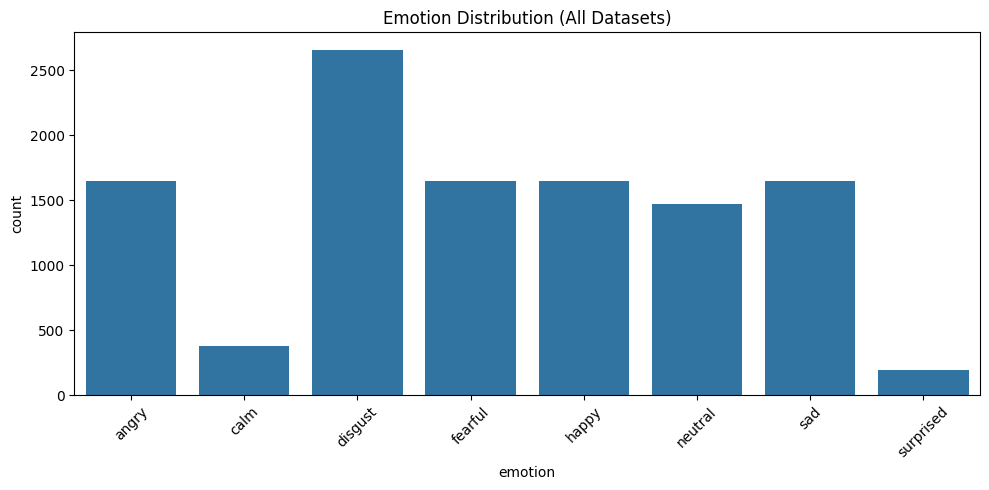

Sample distribution saved


In [ ]:
emotion_list = []
for file in wav_files:
    emotion = get_emotion_from_file(file)
    if emotion:
        emotion_list.append(emotion)

df = pd.DataFrame(emotion_list, columns=["emotion"])
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="emotion", order=emotion_labels)
plt.title("Emotion Distribution (All Datasets)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "emotion_distribution.png"), dpi=150)
plt.show()
print(f"Sample distribution saved")

# Feature Extraction
Combined features: MFCC, Chroma, Mel Spectrogram, Spectral Contrast, Tonnetz, ZCR, RMS

In [ ]:
def extract_features(data, sr, max_len=200):
    """Extract comprehensive audio features - SAME for training and prediction"""
    
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=data, sr=sr)).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T
    
    min_len = min(len(mfcc), len(chroma), len(mel), len(contrast), 
                  len(tonnetz), len(zcr), len(rms))
    
    features = np.hstack([
        mfcc[:min_len], chroma[:min_len], mel[:min_len],
        contrast[:min_len], tonnetz[:min_len], zcr[:min_len], rms[:min_len]
    ])
    
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))
    
    return features

print("Feature extraction function defined ✅")

Feature extraction function defined ✅


# Data Augmentation

In [ ]:
def augment_audio(data, sr):
    """Apply multiple augmentation techniques"""
    augmented_samples = []
    
    # Original
    augmented_samples.append(data)
    
    # 1. White Noise
    noise = np.random.randn(len(data)) * 0.005
    augmented_samples.append(data + noise)
    
    # 2. Time Shift
    shift = int(np.random.randint(-int(sr * 0.1), int(sr * 0.1)))
    augmented_samples.append(np.roll(data, shift))
    
    # 3. Pitch Shift
    try:
        pitch_shift = librosa.effects.pitch_shift(data, sr, n_steps=np.random.uniform(-2, 2))
        augmented_samples.append(pitch_shift)
    except:
        pass
    
    # 4. Time Stretch
    try:
        rate = np.random.uniform(0.8, 1.2)
        stretched = librosa.effects.time_stretch(data, rate=rate)
        augmented_samples.append(stretched[:len(data)])
    except:
        pass
    
    # 5. Volume Change
    gain = np.random.uniform(0.8, 1.2)
    augmented_samples.append(data * gain)
    
    # 6. Add Background Noise (simulated)
    bg_noise = np.random.randn(len(data)) * 0.002
    augmented_samples.append(data + bg_noise)
    
    return augmented_samples

print("✅ Data augmentation functions defined")
print("   - White Noise")
print("   - Time Shift")
print("   - Pitch Shift")
print("   - Time Stretch")
print("   - Volume Change")
print("   - Background Noise")

✅ Data augmentation functions defined
   - White Noise
   - Time Shift
   - Pitch Shift
   - Time Stretch
   - Volume Change
   - Background Noise


# Load and Process Data

In [ ]:
from tensorflow.keras.utils import to_categorical
from joblib import Parallel, delayed
import multiprocessing

def process_file(file):
    try:
        data, sr = librosa.load(file, sr=22050)
    except Exception as e:
        return None, None
    
    primary_emotion = get_emotion_from_file(file)
    
    if primary_emotion is None:
        return None, None
    
    if primary_emotion not in emotion_map:
        return None, None
    
    feature = extract_features(data, sr)
    
    if feature.shape[0] != 200:
        return None, None
    
    label = to_categorical(emotion_map[primary_emotion], num_classes=8)
    
    return feature, label

print(f"Processing: {len(wav_files)} files from all datasets")

num_cores = max(1, min(4, multiprocessing.cpu_count() - 2))
parallel_results = Parallel(n_jobs=num_cores, backend="loky")(
    delayed(process_file)(f) for f in wav_files
)

X, y = [], []
for feat, lab in parallel_results:
    if feat is not None:
        X.append(feat)
        y.append(lab)

X = np.array(X)
y = np.array(y)

print(f"✅ Successfully loaded {len(X)} samples")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Processing: 11291 files from all datasets


/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1012
  warnings.warn(
/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=785
  warnings.warn(
/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=805
  warnings.warn(
/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=748
  warnings.warn(
/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=644
  warnings.warn(
/home/anshu/EmotionDetection-from-voice/venv/lib/pytho

✅ Successfully loaded 11291 samples
Features shape: (11291, 200, 195)
Labels shape: (11291, 8)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)


In [ ]:
y_true = np.argmax(y_test, axis=1)



In [ ]:
mean = np.mean(X_train, axis=0, keepdims=True)
std  = np.std(X_train, axis=0, keepdims=True) + 1e-6


In [ ]:
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)



In [ ]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

y_train_hard = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_hard), y=y_train_hard)
class_weight_dict = dict(zip(np.unique(y_train_hard), class_weights))
print(f"Class weights: {class_weight_dict}")

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
y_train_hard = np.argmax(y_train, axis=1)
y_test_hard = np.argmax(y_test, axis=1)

print(f"Flattened train shape: {X_train_flat.shape}")
print(f"Flattened test shape: {X_test_flat.shape}")

# Model Training
## Training 8 models: CNN, LSTM, CNN+LSTM, CNN+LSTM+Attention, BiLSTM, GRU, MLP, SVM, RandomForest + Ensemble

In [ ]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
        ModelCheckpoint(os.path.join(output_dir, f"best_{model_name}.keras"), 
                        monitor='val_loss', save_best_only=True, verbose=0)
    ]

models = {}
histories = {}
results = {}

print("Starting model training...\n")

In [ ]:
print("="*50)
print("Training CNN model...")
print("="*50)

cnn_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(256, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.4),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

with tf.device("/GPU:0")
cnn_history = cnn_model.fit(X_train, y_train, epochs=30, batch_size=32, 
                           validation_split=0.2, class_weight=class_weight_dict,
                           callbacks=get_callbacks('cnn'), verbose=1)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
models['CNN'] = cnn_model
histories['CNN'] = cnn_history
results['CNN'] = {'loss': cnn_loss, 'accuracy': cnn_acc}
print(f"CNN - Test Accuracy: {cnn_acc:.4f}, Loss: {cnn_loss:.4f}")

In [ ]:
print("="*50)
print("Training LSTM model...")
print("="*50)

lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(8, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

lstm_history = lstm_model.fit(X_train, y_train, epochs=30, batch_size=32,
                              validation_split=0.2, class_weight=class_weight_dict,
                              callbacks=get_callbacks('lstm'), verbose=1)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
models['LSTM'] = lstm_model
histories['LSTM'] = lstm_history
results['LSTM'] = {'loss': lstm_loss, 'accuracy': lstm_acc}
print(f"LSTM - Test Accuracy: {lstm_acc:.4f}, Loss: {lstm_loss:.4f}")

In [ ]:
print("="*50)
print("Training CNN+LSTM model...")
print("="*50)

cnn_lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(8, activation='softmax')
])
cnn_lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_lstm_history = cnn_lstm_model.fit(X_train, y_train, epochs=30, batch_size=32,
                                      validation_split=0.2, class_weight=class_weight_dict,
                                      callbacks=get_callbacks('cnn_lstm'), verbose=1)

cnn_lstm_loss, cnn_lstm_acc = cnn_lstm_model.evaluate(X_test, y_test, verbose=0)
models['CNN+LSTM'] = cnn_lstm_model
histories['CNN+LSTM'] = cnn_lstm_history
results['CNN+LSTM'] = {'loss': cnn_lstm_loss, 'accuracy': cnn_lstm_acc}
print(f"CNN+LSTM - Test Accuracy: {cnn_lstm_acc:.4f}, Loss: {cnn_lstm_loss:.4f}")

In [ ]:
print("="*50)
print("Training CNN+LSTM+Attention model...")
print("="*50)

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = Conv1D(64, 3, padding='same', activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)
x = Conv1D(128, 3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)
attention = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = tf.keras.layers.Add()([x, attention])
x = BatchNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(8, activation='softmax')(x)

cnn_lstm_attn_model = Model(inputs, outputs)
cnn_lstm_attn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_lstm_attn_history = cnn_lstm_attn_model.fit(X_train, y_train, epochs=30, batch_size=32,
                                                 validation_split=0.2, class_weight=class_weight_dict,
                                                 callbacks=get_callbacks('cnn_lstm_attn'), verbose=1)

cnn_lstm_attn_loss, cnn_lstm_attn_acc = cnn_lstm_attn_model.evaluate(X_test, y_test, verbose=0)
models['CNN+LSTM+Attention'] = cnn_lstm_attn_model
histories['CNN+LSTM+Attention'] = cnn_lstm_attn_history
results['CNN+LSTM+Attention'] = {'loss': cnn_lstm_attn_loss, 'accuracy': cnn_lstm_attn_acc}
print(f"CNN+LSTM+Attention - Test Accuracy: {cnn_lstm_attn_acc:.4f}, Loss: {cnn_lstm_attn_loss:.4f}")

In [ ]:
print("="*50)
print("Training BiLSTM model...")
print("="*50)

from tensorflow.keras.layers import GRU 
bilstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])
bilstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

bilstm_history = bilstm_model.fit(X_train, y_train, epochs=30, batch_size=32,
                                  validation_split=0.2, class_weight=class_weight_dict,
                                  callbacks=get_callbacks('bilstm'), verbose=1)

bilstm_loss, bilstm_acc = bilstm_model.evaluate(X_test, y_test, verbose=0)
models['BiLSTM'] = bilstm_model
histories['BiLSTM'] = bilstm_history
results['BiLSTM'] = {'loss': bilstm_loss, 'accuracy': bilstm_acc}
print(f"BiLSTM - Test Accuracy: {bilstm_acc:.4f}, Loss: {bilstm_loss:.4f}")

In [ ]:
print("="*50)
print("Training GRU model...")
print("="*50)

gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(128, return_sequences=True),
    Dropout(0.3),
    GRU(64, return_sequences=True),
    Dropout(0.3),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

gru_history = gru_model.fit(X_train, y_train, epochs=30, batch_size=32,
                           validation_split=0.2, class_weight=class_weight_dict,
                           callbacks=get_callbacks('gru'), verbose=1)

gru_loss, gru_acc = gru_model.evaluate(X_test, y_test, verbose=0)
models['GRU'] = gru_model
histories['GRU'] = gru_history
results['GRU'] = {'loss': gru_loss, 'accuracy': gru_acc}
print(f"GRU - Test Accuracy: {gru_acc:.4f}, Loss: {gru_loss:.4f}")

In [ ]:
print("="*50)
print("Training MLP model...")
print("="*50)

from tensorflow.keras.layers import Flatten, Dense

mlp_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='softmax')
])
mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

mlp_history = mlp_model.fit(X_train, y_train, epochs=30, batch_size=32,
                           validation_split=0.2, class_weight=class_weight_dict,
                           callbacks=get_callbacks('mlp'), verbose=1)

mlp_loss, mlp_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
models['MLP'] = mlp_model
histories['MLP'] = mlp_history
results['MLP'] = {'loss': mlp_loss, 'accuracy': mlp_acc}
print(f"MLP - Test Accuracy: {mlp_acc:.4f}, Loss: {mlp_loss:.4f}")

In [ ]:
print("="*50)
print("Training SVM model...")
print("="*50)

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42, probability=True)
svm_model.fit(X_train_flat, y_train_hard)

svm_pred = svm_model.predict(X_test_flat)
svm_acc = accuracy_score(y_test_hard, svm_pred)
svm_loss = 1 - svm_acc

models['SVM'] = svm_model
results['SVM'] = {'loss': svm_loss, 'accuracy': svm_acc}
print(f"SVM - Test Accuracy: {svm_acc:.4f}")

In [ ]:
print("="*50)
print("Training Random Forest model...")
print("="*50)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_flat, y_train_hard)

rf_pred = rf_model.predict(X_test_flat)
rf_acc = accuracy_score(y_test_hard, rf_pred)
rf_loss = 1 - rf_acc

models['RandomForest'] = rf_model
results['RandomForest'] = {'loss': rf_loss, 'accuracy': rf_acc}
print(f"RandomForest - Test Accuracy: {rf_acc:.4f}")

# Ensemble Model (After Training)

In [ ]:
from scipy.stats import mode

def create_ensemble_predictions(models, X_test, X_test_flat, y_test):
    """Create ensemble predictions using majority voting"""
    all_predictions = []
    
    for name, model in models.items():
        if name in ['SVM', 'RandomForest']:
            preds = model.predict(X_test_flat)
        else:
            preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
        all_predictions.append(preds)
    
    all_predictions = np.array(all_predictions)
    ensemble_preds = mode(all_predictions, axis=0, keepdims=False)[0]
    
    return ensemble_preds

def create_weighted_ensemble(models, X_test, X_test_flat, accuracies):
    """Create weighted ensemble based on model accuracies"""
    total_acc = sum(accuracies.values())
    weights = {k: v/total_acc for k, v in accuracies.items()}
    
    all_probs = []
    for name, model in models.items():
        if name in ['SVM', 'RandomForest']:
            probs = model.predict_proba(X_test_flat)
        else:
            probs = model.predict(X_test, verbose=0)
        all_probs.append(probs * weights[name])
    
    weighted_probs = sum(all_probs)
    return np.argmax(weighted_probs, axis=1)

y_true = np.argmax(y_test, axis=1)

# Filter deep learning models for ensemble
dl_models = {k: v for k, v in models.items() if k not in ['SVM', 'RandomForest']}
dl_accuracies = {k: v['accuracy'] for k, v in results.items() if k not in ['SVM', 'RandomForest']}

ensemble_vote_preds = create_ensemble_predictions(dl_models, X_test, X_test_flat, y_test)
ensemble_weighted_preds = create_weighted_ensemble(dl_models, X_test, X_test_flat, dl_accuracies)

ensemble_vote_acc = accuracy_score(y_true, ensemble_vote_preds)
ensemble_weighted_acc = accuracy_score(y_true, ensemble_weighted_preds)

results['Ensemble_Voting'] = {'loss': 1 - ensemble_vote_acc, 'accuracy': ensemble_vote_acc}
results['Ensemble_Weighted'] = {'loss': 1 - ensemble_weighted_acc, 'accuracy': ensemble_weighted_acc}

print(f"📊 Deep Learning Ensemble Results:")
print(f"   Majority Voting Accuracy: {ensemble_vote_acc:.4f}")
print(f"   Weighted Voting Accuracy: {ensemble_weighted_acc:.4f}")
print(f"\n📈 Comparison with individual models:")
for name, res in results.items():
    print(f"   {name}: {res['accuracy']:.4f}")

# Additional Visualizations - ROC Curves

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC
y_test_bin = label_binarize(y_true, classes=list(range(8)))

n_models = len([k for k in models.keys() if k not in ['SVM', 'RandomForest']])
n_rows = (n_models + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 6 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

dl_models = {k: v for k, v in models.items() if k not in ['SVM', 'RandomForest']}

for idx, (name, model) in enumerate(dl_models.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Get probabilities
    y_prob = model.predict(X_test, verbose=0)
    
    # Compute ROC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(8):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot ROC curves
    colors = plt.cm.tab10(np.linspace(0, 1, 8))
    for i, color in zip(range(8), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{emotion_labels[i]} (AUC = {roc_auc[i]:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} - ROC Curves')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "roc_curves.png"), dpi=150)
plt.show()
print(f"ROC curves saved to {output_dir}/roc_curves.png")

# Per-Class Accuracy Analysis

In [ ]:
# Per-class accuracy for each model
n_models = len(results)
n_rows = (n_models + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    
    if name in ['SVM', 'RandomForest']:
        y_pred = models[name].predict(X_test_flat)
    else:
        y_pred = np.argmax(models[name].predict(X_test, verbose=0), axis=1)
    
    # Calculate per-class accuracy
    per_class_acc = []
    for i in range(8):
        mask = y_true == i
        if mask.sum() > 0:
            acc = (y_pred[mask] == y_true[mask]).mean()
            per_class_acc.append(acc)
        else:
            per_class_acc.append(0)
    
    bars = ax.bar(emotion_labels, per_class_acc, color=plt.cm.Set2(range(8)))
    ax.set_title(f'{name} - Per-Class Accuracy', fontsize=12)
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, acc in zip(bars, per_class_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{acc:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "per_class_accuracy.png"), dpi=150)
plt.show()
print(f"Per-class accuracy saved to {output_dir}/per_class_accuracy.png")

# Model Comparison

In [ ]:
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
losses = [results[m]['loss'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(model_names, accuracies, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=11)

axes[1].bar(model_names, losses, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
axes[1].set_title('Model Loss Comparison', fontsize=14)
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "accuracy_comparison.png"), dpi=150)
plt.show()

## Training Curves

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for idx, (name, history) in enumerate(histories.items()):
    ax = axes[idx // 3, idx % 3]
    ax.plot(history.history['accuracy'], label='Train')
    ax.plot(history.history['val_accuracy'], label='Validation')
    ax.set_title(f'{name} - Training Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "training_curves.png"), dpi=150)
plt.show()

## Confusion Matrices

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for idx, name in enumerate(model_names):
    ax = axes[idx // 3, idx % 3]
    
    if name in ['SVM', 'RandomForest']:
        y_pred = models[name].predict(X_test_flat)
    else:
        y_pred = np.argmax(models[name].predict(X_test, verbose=0), axis=1)
    
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=emotion_labels, yticklabels=emotion_labels, ax=ax)
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrices.png"), dpi=150)
plt.show()

# Best Model Selection

In [ ]:
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']
best_loss = results[best_model_name]['loss']
best_model = models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Loss: {best_loss:.4f}")

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
print("\n" + classification_report(y_true, y_pred, target_names=emotion_labels))

# Save Model and Preprocessors

In [ ]:
with open(os.path.join(output_dir, "emotion_map.pkl"), "wb") as f:
    pickle.dump(emotion_map, f)

with open(os.path.join(output_dir, "normalization.pkl"), "wb") as f:
    pickle.dump({"mean": mean, "std": std}, f)

best_model.save(os.path.join(output_dir, f"final_model_{best_model_name.lower().replace('+', '_')}.keras"))

summary_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [f"{results[m]['accuracy']:.4f}" for m in model_names],
    'Loss': [f"{results[m]['loss']:.4f}" for m in model_names]
})
summary_df.to_csv(os.path.join(output_dir, "model_comparison.csv"), index=False)

print(f"✅ Model and preprocessors saved to {output_dir}/")

---

# Real-time Emotion Prediction

In [ ]:
import sounddevice as sd

def record_audio(duration=3, sr=22050, device=None):
    print("Recording...")
    audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, device=device)
    sd.wait()
    return audio.flatten()

def list_input_devices():
    devices = sd.query_devices()
    print("\n📷 Available Input Devices:\n")
    input_devices = []
    for i, device in enumerate(devices):
        if device['max_input_channels'] > 0:
            print(f"  {i}: {device['name']}")
            input_devices.append(i)
    return input_devices

def extract_feature_prediction(data, sr, max_len=200):
    """Extract features for prediction - SAME as training!"""
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=data, sr=sr)).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T
    
    min_len = min(len(mfcc), len(chroma), len(mel), len(contrast), len(tonnetz), len(zcr), len(rms))
    features = np.hstack([mfcc[:min_len], chroma[:min_len], mel[:min_len], 
                          contrast[:min_len], tonnetz[:min_len], zcr[:min_len], rms[:min_len]])
    
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))
    
    return features

print("✅ Real-time functions defined")

In [ ]:
def predict_from_file(model, file_path, mean, std, emotion_map):
    """Predict emotion from an audio file"""
    audio, sr = librosa.load(file_path, sr=22050)
    
    feature = extract_feature_prediction(audio, sr)
    feature = (feature - mean.squeeze()) / (std.squeeze() + 1e-6)
    feature = np.expand_dims(feature, axis=0)
    
    prediction = model.predict(feature, verbose=0)
    
    inv_map = {v: k for k, v in emotion_map.items()}
    predicted_emotion = inv_map[np.argmax(prediction[0])]
    
    return predicted_emotion, prediction[0], inv_map

def predict_from_mic(model, mean, std, emotion_map, duration=3, device=None):
    """Record and predict emotion from microphone"""
    audio = record_audio(duration=duration, sr=22050, device=device)
    
    feature = extract_feature_prediction(audio, 22050)
    feature = (feature - mean.squeeze()) / (std.squeeze() + 1e-6)
    feature = np.expand_dims(feature, axis=0)
    
    prediction = model.predict(feature, verbose=0)
    
    inv_map = {v: k for k, v in emotion_map.items()}
    predicted_emotion = inv_map[np.argmax(prediction[0])]
    
    return predicted_emotion, prediction[0], inv_map

print("✅ Prediction functions defined")

In [ ]:
# ====== TEST ON RANDOM FILE ======
test_file = random.choice(wav_files)
print(f"Testing file: {test_file}")

predicted_emotion, probs, inv_map = predict_from_file(best_model, test_file, mean, std, emotion_map)
true_emotion = get_emotion_from_file(test_file)

print(f"\n📝 True Emotion: {true_emotion}")
print(f"🔮 Predicted Emotion: {predicted_emotion}")
print(f"\nPrediction probabilities:")
for i, prob in enumerate(probs):
    print(f"  {inv_map[i]}: {prob:.4f}")

In [ ]:
# ====== LIST MICROPHONE DEVICES ======
input_devices = list_input_devices()

In [ ]:
# ====== RECORD FROM MICROPHONE ======
# Uncomment to use:
# device_id = None  # Set to specific device ID or None for default
# duration = 3
# predicted_emotion, probs, inv_map = predict_from_mic(best_model, mean, std, emotion_map, 
#                                                       duration=duration, device=device_id)
# print(f"🔮 Predicted Emotion: {predicted_emotion}")
# for i, prob in enumerate(probs):
#     print(f"  {inv_map[i]}: {prob:.4f}")

# Batch Testing on Multiple Files

In [ ]:
test_files = random.sample(wav_files, min(50, len(wav_files)))
correct = 0
total = 0

for file in test_files:
    try:
        pred_emo, _, _ = predict_from_file(best_model, file, mean, std, emotion_map)
        true_emo = get_emotion_from_file(file)
        
        if true_emo and pred_emo == true_emo:
            correct += 1
        total += 1
    except:
        continue

accuracy = correct / total if total > 0 else 0
print(f"📊 Batch Test Results:")
print(f"   Correct: {correct}/{total}")
print(f"   Accuracy: {accuracy:.2%}")

---

In [ ]:
print("="*60)
print("🎉 COMBINED EMOTION DETECTION COMPLETE!")
print("="*60)
print(f"\n📁 Output directory: {output_dir}")
print(f"🏆 Best model: {best_model_name}")
print(f"📊 Test accuracy: {best_accuracy:.2%}")
print("\n📦 Saved files:")
print(f"   - final_model_{best_model_name.lower().replace('+', '_')}.keras")
print(f"   - emotion_map.pkl")
print(f"   - normalization.pkl")
print(f"   - model_comparison.csv")
print("="*60)